<a href="https://colab.research.google.com/github/VamEmpire/PROJECT_PRACtICE/blob/main/Internship_project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd              # For handling data in table form (DataFrame)
import numpy as np               # For numerical calculations and arrays
import matplotlib.pyplot as plt  # For creating graphs and plots
import seaborn as sns            # For better-looking statistical graphs
import datetime as dt            # For working with dates and time
import time                      # For tracking time or adding delays

import yfinance as yf            # Download stock market data from Yahoo Finance
from pandas_datareader import data as pdr  # Alternative source to fetch financial data
from scipy import stats          # For statistical calculations (mean, variance, etc.)

sns.set_style('whitegrid')       # Sets graph background style to white grid
# Shows plots directly inside Jupyter Notebook
%matplotlib inline

In [2]:
# Define your portfolio and date range
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
weights = np.array([0.25, 0.25, 0.25, 0.25])

start = dt.datetime(2020, 1, 1)   # start date for data
end = dt.datetime.today()         # end date (today)

# Create empty DataFrame to store prices
prices = pd.DataFrame()

for ticker in tickers:
    print(f"Fetching {ticker}...", end=" ")

    try:
        # Download data using yfinance
        df = yf.Ticker(ticker).history(
            start=start.strftime('%Y-%m-%d'),
            end=end.strftime('%Y-%m-%d'),
            auto_adjust=True
        )

        series = df['Close']
        prices[ticker] = series
        print("done (yfinance)")

    except Exception as e:
        # Fallback to stooq if yfinance fails
        print(f"failed yfinance ({e}); using stooq", end=" ")

        df2 = pdr.DataReader(ticker, 'stooq', start, end)
        df2 = df2.sort_index()

        series = df2['Close']
        prices[ticker] = series

        print("done (stooq)")

    time.sleep(1)  # pause to avoid request limits

# Show raw data
print(prices.head(), "\n")

# Clean data
prices = prices.dropna(how='all').ffill().bfill()

# Quick check
print(prices.head(), "\n")
print(prices.size)

Fetching AAPL... done (yfinance)
Fetching MSFT... done (yfinance)
Fetching GOOGL... done (yfinance)
Fetching AMZN... done (yfinance)
                                AAPL        MSFT      GOOGL       AMZN
Date                                                                  
2020-01-02 00:00:00-05:00  72.333885  151.829529  67.832512  94.900497
2020-01-03 00:00:00-05:00  71.630646  149.938995  67.477646  93.748497
2020-01-06 00:00:00-05:00  72.201416  150.326523  69.276222  95.143997
2020-01-07 00:00:00-05:00  71.861862  148.955948  69.142395  95.343002
2020-01-08 00:00:00-05:00  73.017830  151.328568  69.634544  94.598503 

                                AAPL        MSFT      GOOGL       AMZN
Date                                                                  
2020-01-02 00:00:00-05:00  72.333885  151.829529  67.832512  94.900497
2020-01-03 00:00:00-05:00  71.630646  149.938995  67.477646  93.748497
2020-01-06 00:00:00-05:00  72.201416  150.326523  69.276222  95.143997
2020-01-07 00

In [3]:
# Log-return = ln(P_t / P_{t-1})
logR = np.log(prices / prices.shift(1)).dropna()   #dropna() used even if ffill().bfill() used as
print(logR.head(),"\n\n")
print(logR.size)

# Here, 2-Jan data is removed, because we shifted 1 down via using shift(1) and used dropna()

                               AAPL      MSFT     GOOGL      AMZN
Date                                                             
2020-01-03 00:00:00-05:00 -0.009770 -0.012530 -0.005245 -0.012213
2020-01-06 00:00:00-05:00  0.007937  0.002581  0.026305  0.014776
2020-01-07 00:00:00-05:00 -0.004714 -0.009159 -0.001934  0.002089
2020-01-08 00:00:00-05:00  0.015958  0.015803  0.007093 -0.007839
2020-01-09 00:00:00-05:00  0.021019  0.012416  0.010443  0.004788 


6520


In [4]:
summary = pd.DataFrame({'Mean':logR.mean(),'Variance':logR.var(),'Skewness':logR.skew(), 'Kurtosis':logR.kurtosis()})
summary

,Mean,Variance,Skewness,Kurtosis
AAPL,0.000851,0.000390,0.006688,6.373907
MSFT,0.000551,0.000356,-0.229736,7.409552
GOOGL,0.001019,0.000416,-0.094608,3.699168
AMZN,0.000565,0.000497,-0.073669,4.147658


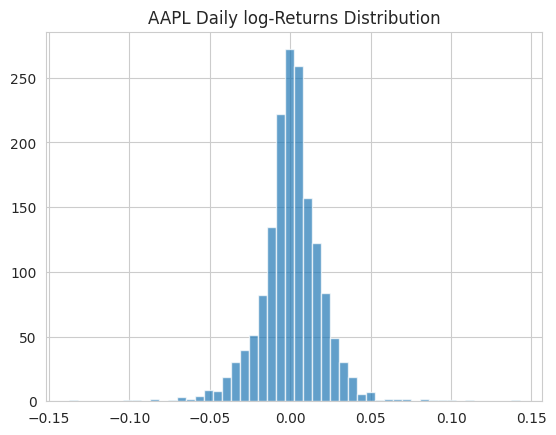

In [5]:
# Plot one example series for visual check
#You'll see a bell-shaped histogram.
logR['AAPL'].hist(bins=50,alpha=0.7)
plt.title("AAPL Daily log-Returns Distribution")
plt.show()

In [6]:
# Mean and standard deviation of log returns
mu_norm = logR.stack().mean()
sigma_norm = logR.stack().std(ddof=1)

#print(mu_norm)
#print(sigma_norm)


#  95% Confidence Interval for Mean

N = logR.size  # total number of observations

z95 = stats.norm.ppf(0.975)  # 95% z-value (1.96)

# Correct CI formula for mean
ci_mu_norm = (
    mu_norm - z95 * sigma_norm / np.sqrt(N),
    mu_norm + z95 * sigma_norm / np.sqrt(N)
)

#print("\n95% CI for Mean\n:", ci_mu_norm)


#95% Confidence Interval for Std Dev ( via chi-square)

df = N - 1  # degrees of freedom

chi2_low, chi2_high = stats.chi2.ppf([0.025, 0.975], df)

ci_sigma_norm = (
    sigma_norm * np.sqrt(df / chi2_high),
    sigma_norm * np.sqrt(df / chi2_low)
)
#print(ci_sigma_norm,"\n\n")

print("\nNormal Fit Results:")
print(f"μ (Mean) = {mu_norm:.5f}, 95% CI = {ci_mu_norm}")
print(f"σ (Std Dev) = {sigma_norm:.5f}, 95% CI = {ci_sigma_norm}")


Normal Fit Results:
μ (Mean) = 0.00075, 95% CI = (np.float64(0.0002524583882565838), np.float64(0.0012407476800740018))
σ (Std Dev) = 0.02036, 95% CI = (np.float64(0.020014256406917928), np.float64(0.020713327455395628))


In [7]:
#4.2 Fit Student's t

#fit t-distribution to the pooled returns
# returns_flat = all asset returns concatenated
returns_flat = logR.stack().values
df_t, mu_t, sigma_t = stats.t.fit(returns_flat)

In [8]:
import numpy as np
from scipy import stats

# 95% CI for μ and σ of a t-fit using bootstrap
B = 1000

estimates = np.array([
    stats.t.fit(np.random.choice(returns_flat, size=N, replace=True))
    for _ in range(B)
])

# estimates columns: [df, mu, sigma]
ci_mu_t = np.percentile(estimates[:, 1], [2.5, 97.5])
ci_sigma_t = np.percentile(estimates[:, 2], [2.5, 97.5])

# Fit once on full data (for reporting)
df_t, mu_t, sigma_t = stats.t.fit(returns_flat)

print("\nStudent's t fit:")
print(f"df = {df_t:.1f}, μ = {mu_t:.5f}, σ = {sigma_t:.5f}")
print(f"95% CI for μ (bootstrap): {ci_mu_t}")
print(f"95% CI for σ (bootstrap): {ci_sigma_t}")


Student's t fit:
df = 3.7, μ = 0.00101, σ = 0.01410
95% CI for μ (bootstrap): [0.00058314 0.00140186]
95% CI for σ (bootstrap): [0.01365541 0.01452214]


In [9]:
# Parametric VaR under Normal:
#  VaR = - [μ_p + σ_p . z_{0.05} ]
# where μ_p, σ_p are portfolio mean & vol.
# Compute portfolio returns:
portR = logR.dot(weights)